<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/image_Classification_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import  tensorflow  as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()
x_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
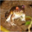

In [5]:
x_train[0]

In [14]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [15]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [16]:
def plot_sample(x,y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(x[index])
  plt.xlabel(classes[y[index]])

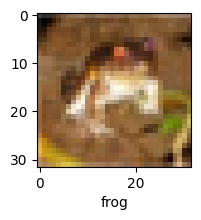

In [17]:
plot_sample(x_train,y_train,0)

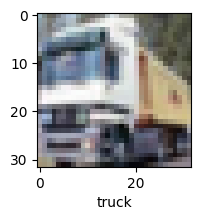

In [18]:
plot_sample(x_train,y_train,1)

In [19]:
x_train=x_train/255
x_test=x_test/255

In [20]:
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation="relu"),
    layers.Dense(1000,activation="relu"),
    layers.Dense(10,activation="sigmoid")
])
ann.compile(optimizer="SGD",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
ann.fit(x_train,y_train,epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3080 - loss: 1.9246
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4255 - loss: 1.6366
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4545 - loss: 1.5471
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4756 - loss: 1.4868
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4875 - loss: 1.4418


In [22]:
ann.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4793 - loss: 1.4893


[1.4938106536865234, 0.47690001130104065]

In [24]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred=ann.predict(x_test)
y_pred_classes=[np.argmax(element) for element in y_pred]
print(classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.62      0.44      0.52      1000
           1       0.76      0.42      0.54      1000
           2       0.37      0.36      0.37      1000
           3       0.36      0.24      0.29      1000
           4       0.42      0.40      0.41      1000
           5       0.31      0.54      0.39      1000
           6       0.47      0.63      0.54      1000
           7       0.52      0.55      0.54      1000
           8       0.61      0.61      0.61      1000
           9       0.59      0.57      0.58      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.48     10000
weighted avg       0.50      0.48      0.48     10000



In [32]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax"),
])
cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
cnn.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3593 - loss: 1.7612
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5626 - loss: 1.2392
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6189 - loss: 1.0880
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6514 - loss: 0.9996
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6690 - loss: 0.9433
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6873 - loss: 0.8903
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6988 - loss: 0.8560
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7107 - loss: 0.8290
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7231 - loss: 0.7891
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7345 - loss: 0.7569


In [33]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6780 - loss: 0.9518


[0.9557074308395386, 0.676800012588501]

In [34]:
y_test=y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

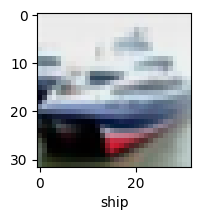

In [35]:
plot_sample(x_test,y_test,1)

In [39]:
y_pred=cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.86218371e-04, 1.13465740e-05, 3.83034057e-04, 8.12361896e-01,
        2.65211891e-03, 1.70622721e-01, 2.48241192e-03, 1.48418374e-04,
        1.11366678e-02, 1.51579025e-05],
       [2.29131384e-03, 5.22570161e-04, 2.16033030e-07, 4.21459163e-06,
        3.62977275e-08, 4.13884429e-08, 1.21682547e-07, 5.82660320e-09,
        9.97153521e-01, 2.79534197e-05],
       [1.19594082e-01, 1.01848625e-01, 2.52134312e-04, 9.22622683e-04,
        2.04590804e-04, 7.96154491e-05, 3.96351767e-04, 1.24201877e-04,
        7.42557824e-01, 3.40199955e-02],
       [7.35220790e-01, 1.48074199e-02, 1.25717102e-02, 4.21397825e-04,
        3.20720766e-03, 2.13535095e-04, 2.91669450e-04, 2.56049243e-04,
        2.31692463e-01, 1.31783134e-03],
       [3.40608472e-06, 6.45951513e-06, 4.37340606e-03, 2.05802452e-02,
        8.95694017e-01, 1.03139970e-02, 6.88468814e-02, 1.05792780e-04,
        7.35163412e-05, 2.26543216e-06]], dtype=float32)

In [40]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [41]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

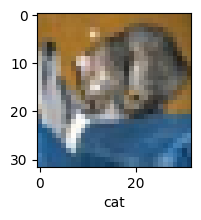

In [42]:
plot_sample(x_test,y_test,0)

In [43]:
classes[y_classes[0]]

'cat'

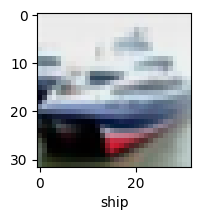

In [44]:
plot_sample(x_test,y_test,1)

In [45]:
classes[y_classes[1]]

'ship'